# Dataset audit

Quick pass over the raw ashwagandha photos before annotating anything: are there
exact duplicate files, weird/inconsistent image dimensions, anything corrupted
that won't even open.

This writes `data/audit_report.json` at the end, which `split_dataset.py` and
`prepare_classifier_data.py` both read later to drop duplicates automatically.
So even though this notebook is meant to be looked at interactively, that JSON
file is a real dependency for the rest of the pipeline -- run the whole thing
top to bottom, don't skip the last cell.

In [1]:
import hashlib
import json
from collections import defaultdict
from pathlib import Path

from PIL import Image, UnidentifiedImageError

# this assumes the notebook is being run from notebooks/, one level under repo root
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = REPO_ROOT / "data" / "raw" / "ashwagandha"
REPORT_PATH = REPO_ROOT / "data" / "audit_report.json"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def list_images(directory):
    return sorted(
        p for p in directory.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


def md5_of_file(path, chunk_size=1 << 16):
    # hash the actual bytes, not the filename -- this is how we catch photos
    # that got saved twice under two different names
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


images = list_images(RAW_DIR)
print(f"found {len(images)} images in {RAW_DIR}")

found 146 images in /home/tj_students/ashwagandha-leaf-detection/data/raw/ashwagandha


In [2]:
hashes = defaultdict(list)
dimensions = defaultdict(int)
corrupt = []

for path in images:
    hashes[md5_of_file(path)].append(path.name)
    try:
        with Image.open(path) as im:
            im.verify()
        with Image.open(path) as im:
            dimensions[f"{im.width}x{im.height}"] += 1
    except (UnidentifiedImageError, OSError):
        corrupt.append(path.name)

duplicate_groups = [names for names in hashes.values() if len(names) > 1]
duplicate_file_count = sum(len(g) - 1 for g in duplicate_groups)

print(f"total images:     {len(images)}")
print(f"unique images:    {len(images) - duplicate_file_count}")
print(f"duplicate groups: {len(duplicate_groups)} ({duplicate_file_count} redundant files)")
print(f"dimensions seen:  {dict(dimensions)}")
print(f"corrupt files:    {corrupt if corrupt else 'none'}")

total images:     146
unique images:    140
duplicate groups: 6 (6 redundant files)
dimensions seen:  {'600x450': 146}
corrupt files:    none


### what do the duplicate pairs actually look like?

Worth eyeballing these before deciding to drop them -- just confirming they're
genuinely the same photo saved twice, not two different photos that happen to
hash the same (which basically never happens with MD5, but still, good to check).

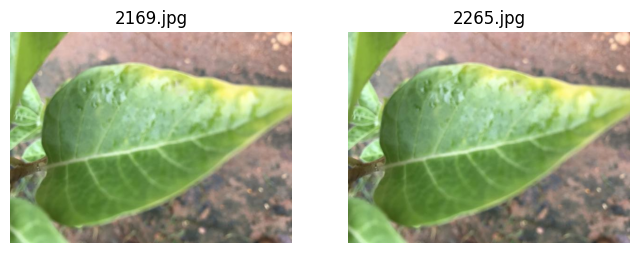

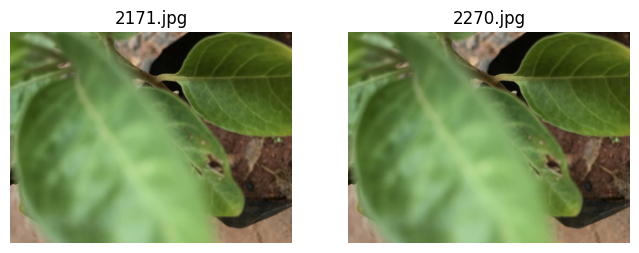

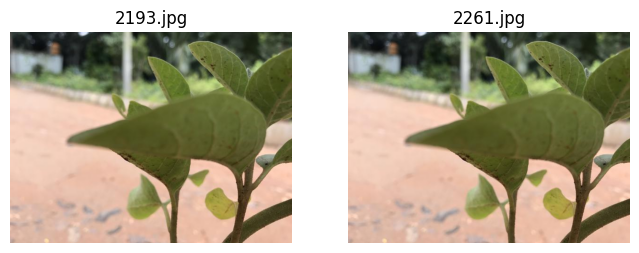

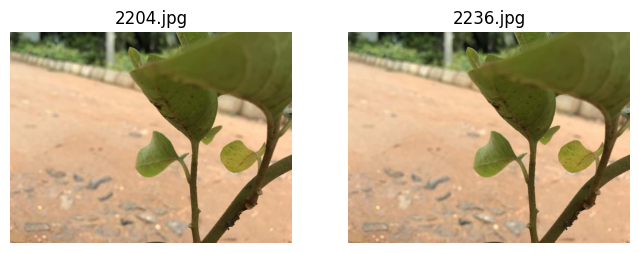

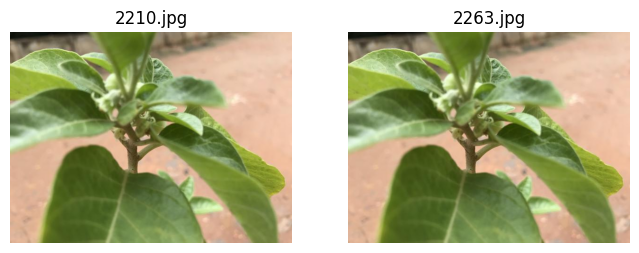

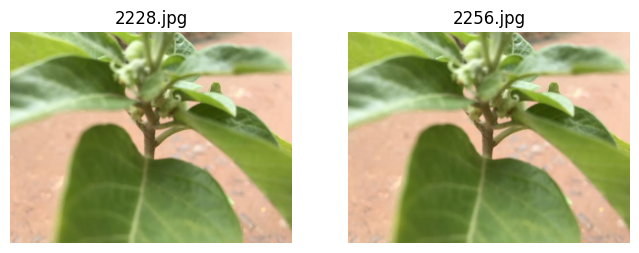

In [3]:
import matplotlib.pyplot as plt

for group in duplicate_groups:
    fig, axes = plt.subplots(1, len(group), figsize=(4 * len(group), 4))
    if len(group) == 1:
        axes = [axes]
    for ax, name in zip(axes, group):
        ax.imshow(Image.open(RAW_DIR / name))
        ax.set_title(name)
        ax.axis("off")
    plt.show()

### saving the report

Same JSON shape the old `audit_dataset.py` script used to write, so nothing
downstream needs to change.

In [4]:
report = {
    "directory": str(RAW_DIR),
    "total_images": len(images),
    "unique_images": len(images) - duplicate_file_count,
    "duplicate_groups": duplicate_groups,
    "duplicate_file_count": duplicate_file_count,
    "dimensions": dict(dimensions),
    "corrupt_files": corrupt,
}

REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
REPORT_PATH.write_text(json.dumps(report, indent=2))
print(f"wrote {REPORT_PATH}")

wrote /home/tj_students/ashwagandha-leaf-detection/data/audit_report.json


Next: if you haven't already, review the auto-labeled boxes in CVAT and
export them to `data/detect/cvat_import.zip`, then run `scripts/split_dataset.py`
to build the actual train/val/test dataset.